## Personal Notebook, Random Forest, Jani Laakso

##### Using the cleaned_100k.csv and the same skeleton as in the assignment notebook.

### Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.model_selection import cross_val_score
from imblearn.pipeline import Pipeline          # NOT sklearn's Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (classification_report,
                            ConfusionMatrixDisplay,
                            accuracy_score, f1_score)
import seaborn as sns

### Reading sampled csv and splitting data 60/20/20

In [2]:
df = pd.read_csv("cleaned_100k.csv", low_memory=False)

y = df["Attack Type"]
X = df.drop("Attack Type", axis=1)

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=0.25, random_state=42, stratify=y_train_val)

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)

Train: (60000, 52) Val: (20000, 52) Test: (20000, 52)


### Creating skeleton

In [3]:
# ---- Agreed 10-feature list ------------------------------------------
FEATURES = [
    "Flow Duration",
    "Total Fwd Packets",
    "Total Length of Fwd Packets",
    "Flow Bytes/s",
    "Flow Packets/s",
    "Fwd Packet Length Mean",
    "Bwd Packet Length Mean",
    "Packet Length Mean",
    "Packet Length Std",
    "Average Packet Size",
]
missing = [f for f in FEATURES if f not in X_train.columns]
assert not missing, f"These features are not in the data: {missing}"

X_train_sel = X_train[FEATURES]
X_val_sel   = X_val[FEATURES]
X_test_sel  = X_test[FEATURES]

CV_FOLDS = 5
SCORING  = "f1_macro"
N_JOBS   = -1

def run_experiment(clf, param_grid, label, use_smote=True, use_pca=True):
    """Fit Pipeline+GridSearchCV and return a results dict."""
    steps = [("scaler", StandardScaler())]
    steps.append(("pca",   PCA() if use_pca else "passthrough"))
    steps.append(("smote", SMOTE(random_state=42) if use_smote else "passthrough"))
    steps.append(("clf",   clf))
    pipe = Pipeline(steps)

    grid = GridSearchCV(pipe, param_grid=param_grid,
                        cv=CV_FOLDS, scoring=SCORING,
                        n_jobs=N_JOBS, verbose=1)
    grid.fit(X_train_sel, y_train)

    y_val_pred  = grid.predict(X_val_sel)
    y_test_pred = grid.predict(X_test_sel)

    val_acc  = accuracy_score(y_val,  y_val_pred)
    val_f1   = f1_score(y_val, y_val_pred, average="macro")
    test_acc = accuracy_score(y_test, y_test_pred)
    test_f1  = f1_score(y_test, y_test_pred, average="macro")

    fig, ax = plt.subplots(figsize=(7, 6))
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_test_pred, ax=ax, xticks_rotation=45, colorbar=False)
    ax.set_title(f"{label} — test confusion matrix")
    plt.tight_layout()
    plt.show()

    print(f"\n=== {label} ===")
    print("Best params :", grid.best_params_)
    print(f"Val  acc={val_acc:.4f}  f1_macro={val_f1:.4f}")
    print(f"Test acc={test_acc:.4f}  f1_macro={test_f1:.4f}")
    print(classification_report(y_test, y_test_pred, digits=3))

    return {
        "label":         label,
        "best_params":   grid.best_params_,
        "val_acc":       val_acc,
        "val_f1_macro":  val_f1,
        "test_acc":      test_acc,
        "test_f1_macro": test_f1,
        "smote":         use_smote,
        "pca":           use_pca,
    }

all_results = []

Fitting 5 folds for each of 12 candidates, totalling 60 fits


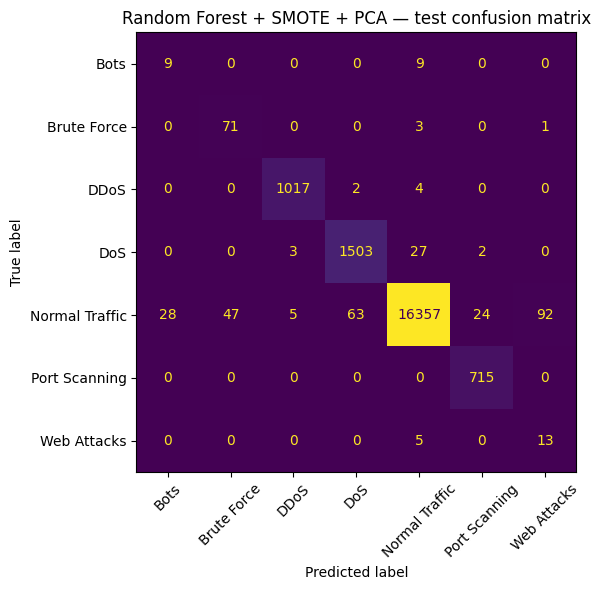


=== Random Forest + SMOTE + PCA ===
Best params : {'clf__class_weight': 'balanced', 'clf__max_depth': None, 'clf__min_samples_split': 5, 'clf__n_estimators': 100, 'pca__n_components': 8}
Val  acc=0.9843  f1_macro=0.7458
Test acc=0.9842  f1_macro=0.7439
                precision    recall  f1-score   support

          Bots      0.243     0.500     0.327        18
   Brute Force      0.602     0.947     0.736        75
          DDoS      0.992     0.994     0.993      1023
           DoS      0.959     0.979     0.969      1535
Normal Traffic      0.997     0.984     0.991     16616
 Port Scanning      0.965     1.000     0.982       715
   Web Attacks      0.123     0.722     0.210        18

      accuracy                          0.984     20000
     macro avg      0.697     0.875     0.744     20000
  weighted avg      0.990     0.984     0.987     20000

Fitting 5 folds for each of 12 candidates, totalling 60 fits


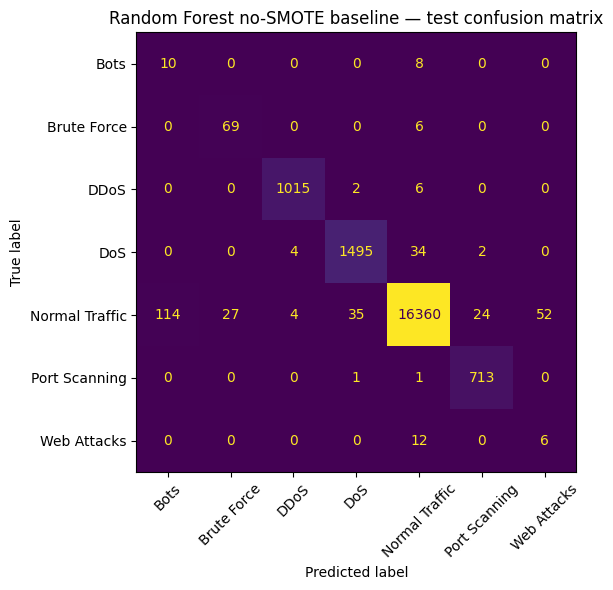


=== Random Forest no-SMOTE baseline ===
Best params : {'clf__class_weight': 'balanced', 'clf__max_depth': 15, 'clf__min_samples_split': 5, 'clf__n_estimators': 100, 'pca__n_components': 8}
Val  acc=0.9835  f1_macro=0.7095
Test acc=0.9834  f1_macro=0.7205
                precision    recall  f1-score   support

          Bots      0.081     0.556     0.141        18
   Brute Force      0.719     0.920     0.807        75
          DDoS      0.992     0.992     0.992      1023
           DoS      0.975     0.974     0.975      1535
Normal Traffic      0.996     0.985     0.990     16616
 Port Scanning      0.965     0.997     0.981       715
   Web Attacks      0.103     0.333     0.158        18

      accuracy                          0.983     20000
     macro avg      0.690     0.822     0.720     20000
  weighted avg      0.990     0.983     0.987     20000



In [4]:
from sklearn.ensemble import RandomForestClassifier

rf_param_grid = {
    "pca__n_components": [4, 6, 8],          # how much PCA compresses
    "clf__n_estimators":  [50, 100],          # more trees = better, but slower
    "clf__max_depth":     [None, 15],      # None = fully grown trees
    "clf__min_samples_split": [5],         # min samples to split a node
    "clf__class_weight":  ["balanced"],  # handles imbalance without SMOTE
}

# Run 1: with SMOTE (primary experiment)
all_results.append(
    run_experiment(
        RandomForestClassifier(random_state=42, n_jobs=-1),
        rf_param_grid,
        label="Random Forest + SMOTE + PCA"
    )
)

# Run 2: no-SMOTE baseline (for comparison)
all_results.append(
    run_experiment(
        RandomForestClassifier(random_state=42, n_jobs=-1),
        rf_param_grid,
        label="Random Forest no-SMOTE baseline",
        use_smote=False
    )
)
